In [1]:
import pandas as pd
import numpy as np
import gc
from pathlib import Path
from tqdm.auto import tqdm

# Custom project imports
from wtfd.models.trainer import WindFaultTrainer
from wtfd.models.splitter import WindFarmSplitter

# 1. Path Setup
PROJ_ROOT = Path("..")
DATA_PATH = PROJ_ROOT / "data" / "processed_v3" / "master_dataset.parquet"

# 2. Load & Split Features
print(f"Loading v3 dataset...")
df = pd.read_parquet(DATA_PATH)
features = [c for c in df.columns if c not in ['time_stamp', 'asset_id', 'farm_id', 'target', 'event_id']]

splitter = WindFarmSplitter(n_splits=5, random_state=42)
dev_df, holdout_df = splitter.get_train_test_split(df, test_size=0.2)

print(f"Dev Turbines: {dev_df['asset_id'].nunique()} | Holdout Turbines: {holdout_df['asset_id'].nunique()}")
del df
gc.collect()

# 3. The Tournament Loop
# model_types = ['logistic', 'rf', 'xgboost']
model_types = ['xgboost', 'rf', 'logistic']
tournament_results = []

for m_type in tqdm(model_types, desc="Model Tournament"):
    trainer = WindFaultTrainer(model_type=m_type, random_state=42)
    cv_iterator = list(splitter.get_cv_iter(dev_df))
    fold_f1s = []
    
    print(f"\n--- Starting {m_type.upper()} CV ---")
    
    for fold, (train_idx, val_idx) in enumerate(tqdm(cv_iterator, desc=f"CV ({m_type})", leave=False)):
        # Use .iloc and create copies to avoid SettingWithCopy warnings and memory fragmentation
        X_train, y_train = dev_df.iloc[train_idx][features].copy(), dev_df.iloc[train_idx]['target'].copy()
        X_val, y_val = dev_df.iloc[val_idx][features].copy(), dev_df.iloc[val_idx]['target'].copy()
        
        # Train (Pipeline handles Scaling + Threshold Tuning)
        trainer.train(X_train, y_train)
        
        # Diagnostics: Predict Proba before evaluate clears memory
        probs = trainer.model.predict_proba(X_val)[:, 1]
        m = trainer.evaluate(X_val, y_val)
        
        print(f"\n[Fold {fold+1} Diagnostics - {m_type.upper()}]")
        print(f"  Positives (Train/Val): {y_train.sum()} / {y_val.sum()}")
        print(f"  Max Prob: {probs.max():.4f} | Mean Prob: {probs.mean():.4f}")
        print(f"  Samples > 0.5: {(probs > 0.5).sum()}")
        print(f"  Tuned Threshold: {m['threshold']:.4f} | F1: {m['f1']:.4f}")
        
        fold_f1s.append(m['f1'])
        
        # Hard cleanup
        del X_train, y_train, X_val, y_val, probs
        gc.collect()
        
    # 4. Final Holdout Reveal
    X_dev, y_dev = dev_df[features], dev_df['target']
    X_hold, y_hold = holdout_df[features], holdout_df['target']
    
    trainer.train(X_dev, y_dev)
    holdout_metrics = trainer.evaluate(X_hold, y_hold)
    
    tournament_results.append({
        'model': m_type,
        'cv_f1_mean': np.mean(fold_f1s),
        'holdout_f1': holdout_metrics['f1'],
        'holdout_auc': holdout_metrics['auc']
    })
    
    print(f"\n>>> {m_type.upper()} FINAL HOLDOUT F1: {holdout_metrics['f1']:.4f}")
    del trainer
    gc.collect()

# 5. Standings
standings = pd.DataFrame(tournament_results).set_index('model')
display(standings)

Loading v3 dataset...
Dev Turbines: 24 | Holdout Turbines: 8


Model Tournament:   0%|          | 0/3 [00:00<?, ?it/s]


--- Starting XGBOOST CV ---


CV (xgboost):   0%|          | 0/5 [00:00<?, ?it/s]


[Fold 1 Diagnostics - XGBOOST]
  Positives (Train/Val): 76638 / 23872
  Max Prob: 0.9839 | Mean Prob: 0.1233
  Samples > 0.5: 43150
  Tuned Threshold: 0.8728 | F1: 0.0195

[Fold 2 Diagnostics - XGBOOST]
  Positives (Train/Val): 84691 / 15819
  Max Prob: 0.9810 | Mean Prob: 0.1957
  Samples > 0.5: 115781
  Tuned Threshold: 0.8773 | F1: 0.0011

[Fold 3 Diagnostics - XGBOOST]
  Positives (Train/Val): 76506 / 24004
  Max Prob: 0.9617 | Mean Prob: 0.1983
  Samples > 0.5: 108828
  Tuned Threshold: 0.8668 | F1: 0.0456

[Fold 4 Diagnostics - XGBOOST]
  Positives (Train/Val): 83230 / 17280
  Max Prob: 0.9900 | Mean Prob: 0.1652
  Samples > 0.5: 108460
  Tuned Threshold: 0.8519 | F1: 0.1189

[Fold 5 Diagnostics - XGBOOST]
  Positives (Train/Val): 80975 / 19535
  Max Prob: 0.9758 | Mean Prob: 0.2422
  Samples > 0.5: 180840
  Tuned Threshold: 0.8684 | F1: 0.0006

>>> XGBOOST FINAL HOLDOUT F1: 0.3196

--- Starting RF CV ---


CV (rf):   0%|          | 0/5 [00:00<?, ?it/s]


[Fold 1 Diagnostics - RF]
  Positives (Train/Val): 76638 / 23872
  Max Prob: 0.9003 | Mean Prob: 0.2722
  Samples > 0.5: 35021
  Tuned Threshold: 0.8107 | F1: 0.0155

[Fold 2 Diagnostics - RF]
  Positives (Train/Val): 84691 / 15819
  Max Prob: 0.9118 | Mean Prob: 0.2674
  Samples > 0.5: 74797
  Tuned Threshold: 0.7883 | F1: 0.0000

[Fold 3 Diagnostics - RF]
  Positives (Train/Val): 76506 / 24004
  Max Prob: 0.9135 | Mean Prob: 0.2768
  Samples > 0.5: 84276
  Tuned Threshold: 0.7551 | F1: 0.0639

[Fold 4 Diagnostics - RF]
  Positives (Train/Val): 83230 / 17280
  Max Prob: 0.8813 | Mean Prob: 0.2635
  Samples > 0.5: 88669
  Tuned Threshold: 0.7431 | F1: 0.1671

[Fold 5 Diagnostics - RF]
  Positives (Train/Val): 80975 / 19535
  Max Prob: 0.8717 | Mean Prob: 0.3299
  Samples > 0.5: 181627
  Tuned Threshold: 0.7084 | F1: 0.0000

>>> RF FINAL HOLDOUT F1: 0.2666

--- Starting LOGISTIC CV ---


CV (logistic):   0%|          | 0/5 [00:00<?, ?it/s]


[Fold 1 Diagnostics - LOGISTIC]
  Positives (Train/Val): 76638 / 23872
  Max Prob: 0.8748 | Mean Prob: 0.4193
  Samples > 0.5: 211422
  Tuned Threshold: 0.6470 | F1: 0.1045

[Fold 2 Diagnostics - LOGISTIC]
  Positives (Train/Val): 84691 / 15819
  Max Prob: 0.8950 | Mean Prob: 0.4775
  Samples > 0.5: 373688
  Tuned Threshold: 0.6649 | F1: 0.0122

[Fold 3 Diagnostics - LOGISTIC]
  Positives (Train/Val): 76506 / 24004
  Max Prob: 0.9166 | Mean Prob: 0.4358
  Samples > 0.5: 299098
  Tuned Threshold: 0.6742 | F1: 0.0247

[Fold 4 Diagnostics - LOGISTIC]
  Positives (Train/Val): 83230 / 17280
  Max Prob: 1.0000 | Mean Prob: 0.4023
  Samples > 0.5: 214933
  Tuned Threshold: 0.6158 | F1: 0.0487

[Fold 5 Diagnostics - LOGISTIC]
  Positives (Train/Val): 80975 / 19535
  Max Prob: 1.0000 | Mean Prob: 0.4993
  Samples > 0.5: 428517
  Tuned Threshold: 0.6807 | F1: 0.0714

>>> LOGISTIC FINAL HOLDOUT F1: 0.1250


,cv_f1_mean,holdout_f1,holdout_auc
model,,,
xgboost,0.037148,0.319611,0.799767
rf,0.049307,0.266570,0.781932
logistic,0.052298,0.125025,0.714127


## Sandbox

Re-training XGBoost for Visualization...
--- Analysis for Turbine 13 ---
Samples Correctly Predicted (TP): 2803
False Alarm Samples (FP): 4334


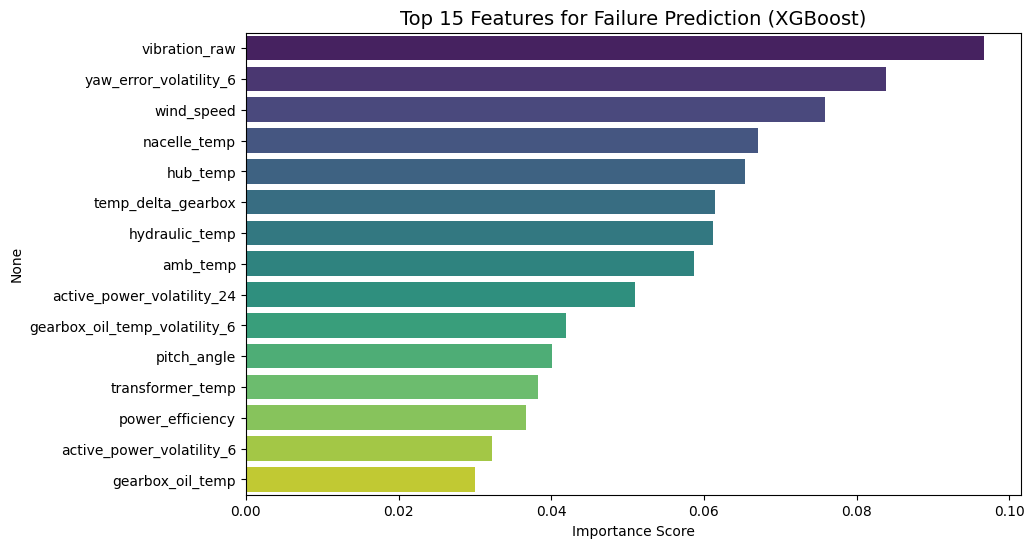

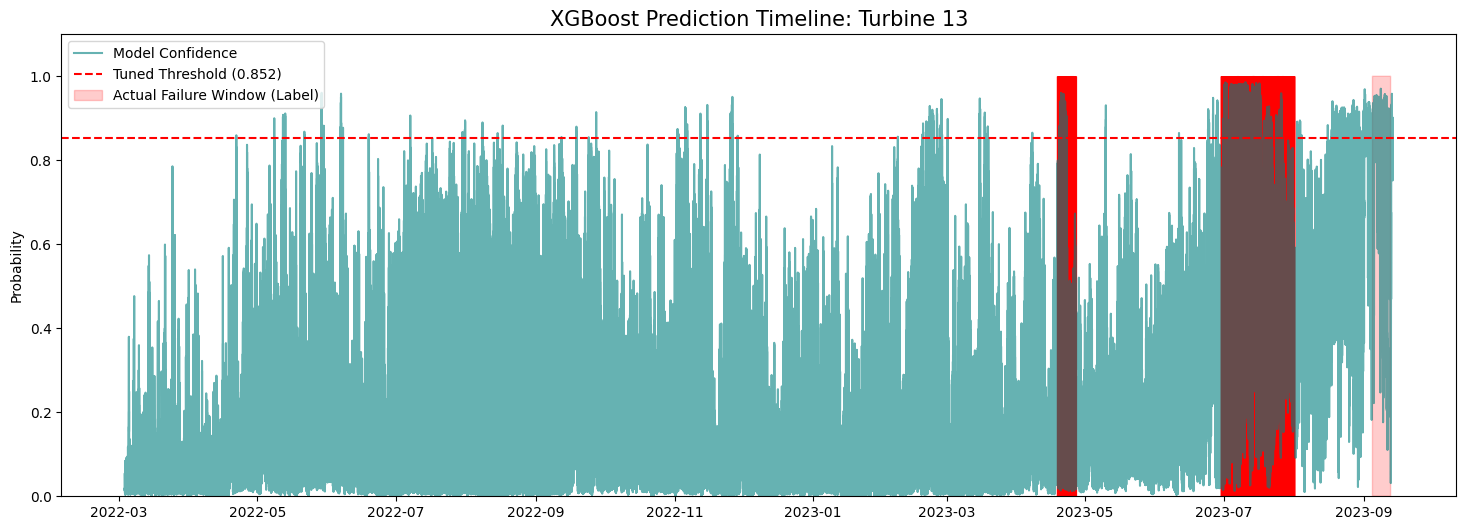

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-initialize and Train the Winning Model (XGBoost)
print("Re-training XGBoost for Visualization...")
vis_trainer = WindFaultTrainer(model_type='xgboost', random_state=42)
vis_trainer.train(dev_df[features], dev_df['target'])

# 2. Generate Holdout Predictions
holdout_df = holdout_df.copy() # Avoid slice warnings
holdout_df['pred_prob'] = vis_trainer.model.predict_proba(holdout_df[features])[:, 1]

# 3. Feature Importance Plot
if hasattr(vis_trainer.model.named_steps['model'], 'feature_importances_'):
    importances = vis_trainer.model.named_steps['model'].feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='viridis', legend=False)
    plt.title("Top 15 Features for Failure Prediction (XGBoost)", fontsize=14)
    plt.xlabel("Importance Score")

# 4. Timeline Analysis for a Specific Failed Turbine
failed_turbines = holdout_df[holdout_df['target'] == 1]['asset_id'].unique()
if len(failed_turbines) > 0:
    target_turbine = failed_turbines[0] 
    plot_df = holdout_df[holdout_df['asset_id'] == target_turbine].sort_values('time_stamp')

    plt.figure(figsize=(18, 6))
    # Probability Line
    plt.plot(plot_df['time_stamp'], plot_df['pred_prob'], label='Model Confidence', color='teal', alpha=0.6)
    # Tuned Threshold
    plt.axhline(y=vis_trainer.best_threshold, color='red', linestyle='--', 
                label=f'Tuned Threshold ({vis_trainer.best_threshold:.3f})')
    # Actual Failure Background
    plt.fill_between(plot_df['time_stamp'], 0, 1, where=plot_df['target']==1, 
                     color='red', alpha=0.2, label='Actual Failure Window (Label)')

    plt.title(f"XGBoost Prediction Timeline: Turbine {target_turbine}", fontsize=15)
    plt.ylabel("Probability")
    plt.ylim(0, 1.1)
    plt.legend(loc='upper left')

    # Lead-Time Diagnostic
    tp = ((plot_df['pred_prob'] >= vis_trainer.best_threshold) & (plot_df['target'] == 1)).sum()
    fp = ((plot_df['pred_prob'] >= vis_trainer.best_threshold) & (plot_df['target'] == 0)).sum()
    print(f"--- Analysis for Turbine {target_turbine} ---")
    print(f"Samples Correctly Predicted (TP): {tp}")
    print(f"False Alarm Samples (FP): {fp}")
else:
    print("No failures found in holdout set to visualize.")